In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from scipy import stats
import xarray as xr
import pandas as pd
import pystan


## Load KC data

In [2]:
#function to load data and compute the correlation distance matrix from it
def get_KC_dmat(fname):
    #load data
    data = xr.load_dataset(fname)
    #get odors
    stim_list = data.stim.to_numpy()
    odors = np.unique(stim_list)
    #get Fc_zscore neural data
    neuron_dat = data.Fc_zscore.to_numpy()
    
    N = odors.shape[0]
    dmat = np.zeros((N,N))
    
    for i in np.arange(N):
        for j in np.arange(i+1, N):
            #average over trials of each odor
            x1 = np.mean(neuron_dat[np.where(stim_list == odors[i])], axis=0)
            x2 = np.mean(neuron_dat[np.where(stim_list == odors[j])], axis=0)
            #compute correlation distance
            dmat[i][j] = np.sqrt(1-stats.pearsonr(x1, x2)[0])
            dmat[j][i] = dmat[i][j]
            
    #normalize distance matrix
    dmat = 2.0*dmat/np.max(dmat)
    return odors, dmat

In [3]:
#loop through data files and compute distance matrices
#you will have to insert your own path to the data here
files = !ls data_files/megamat17/2022*/respvec/xrds_suite2p_respvec_mean_peak.nc
files = [fn[5:-6] for fn in files]

all_odors_17 = []
all_dmats_17 = []

for fn in files:
    tmp = get_KC_dmat(fn)
    all_odors_17.append(tmp[0])
    all_dmats_17.append(tmp[1])

Text(0.5, 1.0, 'distance distribution')

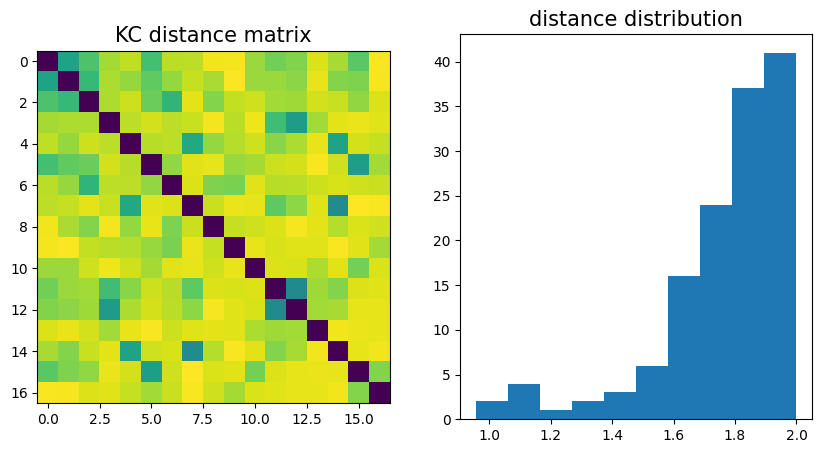

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
i=2
ax[0].imshow(all_dmats_17[i])
ax[1].hist(all_dmats_17[i][np.triu_indices(all_dmats_17[i].shape[0], k=1)])
ax[0].set_title('KC distance matrix', fontsize=15)
ax[1].set_title('distance distribution', fontsize=15)

## Hyperbolic embeddings

In [9]:
#load and compile code
HMDS_code = """ 
functions {
    //hyperbolic distance between points in lorentz coordinates
    real hyp(real t1, real t2, vector E1, vector E2){
        real xi = t1*t2 - dot_product(E1, E2);
        if (xi <= 1)
            return 0.0;
        else
            return acosh(xi);
    }
}
data {
    int<lower=0> N;        // number of points
    int<lower=0> D;        // Dimension of space
    matrix[N, N] deltaij;  // matrix of data distances, only upper triangle will be operated on
}
transformed data {
    real Nterms = 0.5*N*(N-1);
}
parameters {
    vector[D] euc[N];               //x1-xd coordinates in lorentz space
    vector<lower=0.0>[N] sig;       //embedding uncertainties
    real<lower=0.001> lambda;       //scale parameter
}
transformed parameters {
    vector[N] time;      //xo coordinates in lorentz space, solve for from constraint eqs
    
    for (i in 1:N)
        time[i] = sqrt(1.0 + dot_self(euc[i]));
}
model {
    real dist;
    real seff;
    
    //normal prior on scale parameter
    target += -Nterms*0.5*square(lambda)/square(10.0);
      
    //inverse gamma priors on uncertainties
    for (i in 1:N)
        sig[i] ~ inv_gamma(2.0, 0.5);
    
    //loop over all pairs
    for(i in 1:N){
        for (j in i+1:N){
            if (deltaij[i,j] > 0.0){
                //compute embedding distance and effective uncertainties
                dist = hyp(time[i], time[j], euc[i], euc[j]);
                seff = sqrt(square(sig[i]) + square(sig[j]));

                //data distances normally distributed about embedding distance
                deltaij[i,j] ~ normal(dist/lambda, seff);
            }
        }
    }
}
"""
hmds_m = pystan.StanModel(model_code=HMDS_code, verbose=False)

INFO:pystan:COMPILING THE C++ CODE FOR MODEL anon_model_c83bbe7ae7cc9b8231ab55b6d5f9d111 NOW.
clang: warning: -Wl,-export_dynamic: 'linker' input unused [-Wunused-command-line-argument]
In file included from /var/folders/_7/9jmhbjfd0sjg_0rdpmhmjdgh0000gp/T/pystan_vuy81q8o/stanfit4anon_model_c83bbe7ae7cc9b8231ab55b6d5f9d111_8962700443352895419.cpp:848:
In file included from /opt/anaconda3/lib/python3.8/site-packages/numpy/core/include/numpy/arrayobject.h:5:
In file included from /opt/anaconda3/lib/python3.8/site-packages/numpy/core/include/numpy/ndarrayobject.h:12:
In file included from /opt/anaconda3/lib/python3.8/site-packages/numpy/core/include/numpy/ndarraytypes.h:1948:
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: "Using deprecated NumPy API, disable it with "          "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-W#warnings]
#warning "Using deprecated NumPy API, disable it with " \
 ^
In file included from /var/

In file included from /var/folders/_7/9jmhbjfd0sjg_0rdpmhmjdgh0000gp/T/pystan_vuy81q8o/stanfit4anon_model_c83bbe7ae7cc9b8231ab55b6d5f9d111_8962700443352895419.cpp:858:
/opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan_fit.hpp:841:12: warning: 'auto_ptr<stan::io::var_context>' is deprecated [-Wdeprecated-declarations]
      std::auto_ptr<stan::io::var_context> init_context_ptr;
           ^
/Library/Developer/CommandLineTools/SDKs/MacOSX.sdk/usr/include/c++/v1/memory:1851:28: note: 'auto_ptr<stan::io::var_context>' has been explicitly marked deprecated here
class _LIBCPP_TEMPLATE_VIS _LIBCPP_DEPRECATED_IN_CXX11 auto_ptr
                           ^
/Library/Developer/CommandLineTools/SDKs/MacOSX.sdk/usr/include/c++/v1/__config:1046:39: note: expanded from macro '_LIBCPP_DEPRECATED_IN_CXX11'
#  define _LIBCPP_DEPRECATED_IN_CXX11 _LIBCPP_DEPRECATED
                                      ^
/Library/Developer/CommandLineTools/SDKs/MacOSX

In file included from /var/folders/_7/9jmhbjfd0sjg_0rdpmhmjdgh0000gp/T/pystan_vuy81q8o/stanfit4anon_model_c83bbe7ae7cc9b8231ab55b6d5f9d111_8962700443352895419.cpp:857:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/py_var_context.hpp:12:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/src/stan/io/dump.hpp:6:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim.hpp:6:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim/core.hpp:4:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim/core/init_threadpool_tbb.hpp:4:
In file included 

In file included from /var/folders/_7/9jmhbjfd0sjg_0rdpmhmjdgh0000gp/T/pystan_vuy81q8o/stanfit4anon_model_c83bbe7ae7cc9b8231ab55b6d5f9d111_8962700443352895419.cpp:857:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/py_var_context.hpp:12:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/src/stan/io/dump.hpp:6:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim.hpp:6:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim/core.hpp:4:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim/core/init_threadpool_tbb.hpp:4:
In file included 

In file included from /var/folders/_7/9jmhbjfd0sjg_0rdpmhmjdgh0000gp/T/pystan_vuy81q8o/stanfit4anon_model_c83bbe7ae7cc9b8231ab55b6d5f9d111_8962700443352895419.cpp:857:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/py_var_context.hpp:12:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/src/stan/io/dump.hpp:6:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim.hpp:6:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim/core.hpp:4:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim/core/init_threadpool_tbb.hpp:4:
In file included 

...

In file included from /var/folders/_7/9jmhbjfd0sjg_0rdpmhmjdgh0000gp/T/pystan_vuy81q8o/stanfit4anon_model_c83bbe7ae7cc9b8231ab55b6d5f9d111_8962700443352895419.cpp:857:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/py_var_context.hpp:12:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/src/stan/io/dump.hpp:6:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim.hpp:6:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim/core.hpp:4:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim/core/init_threadpool_tbb.hpp:4:
In file included 

In file included from /var/folders/_7/9jmhbjfd0sjg_0rdpmhmjdgh0000gp/T/pystan_vuy81q8o/stanfit4anon_model_c83bbe7ae7cc9b8231ab55b6d5f9d111_8962700443352895419.cpp:857:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/py_var_context.hpp:12:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/src/stan/io/dump.hpp:6:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim.hpp:6:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim/core.hpp:4:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim/core/init_threadpool_tbb.hpp:4:
In file included 

In file included from /var/folders/_7/9jmhbjfd0sjg_0rdpmhmjdgh0000gp/T/pystan_vuy81q8o/stanfit4anon_model_c83bbe7ae7cc9b8231ab55b6d5f9d111_8962700443352895419.cpp:857:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/py_var_context.hpp:12:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/src/stan/io/dump.hpp:6:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim.hpp:6:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim/core.hpp:4:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim/core/init_threadpool_tbb.hpp:4:
In file included 

In file included from /var/folders/_7/9jmhbjfd0sjg_0rdpmhmjdgh0000gp/T/pystan_vuy81q8o/stanfit4anon_model_c83bbe7ae7cc9b8231ab55b6d5f9d111_8962700443352895419.cpp:857:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/py_var_context.hpp:12:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/src/stan/io/dump.hpp:6:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim.hpp:6:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim/core.hpp:4:
In file included from /opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/stan/math/prim/core/init_threadpool_tbb.hpp:4:
In file included 

219 warnings generated.
ld: warning: -pie being ignored. It is only used when linking a main executable
ld: warning: dylib (/opt/anaconda3/lib/python3.8/site-packages/pystan-2.22.1.0.dev0-py3.8-macosx-10.9-x86_64.egg/pystan/stan/lib/stan_math/lib/tbb/libtbb.dylib) was built for newer macOS version (11.0) than being linked (10.9)


In [10]:
#code for processing embeddings

#######################################################################################################

# hyperbolic distance between poincare coordinates of 2 points
def pdist(p1, p2):
    inv = 2.0*(p1-p2).dot(p1-p2)/((1-p1.dot(p1))*(1-p2.dot(p2)))
    return np.arccosh(1.0 + inv)

# return distance matrix from a collection of points in their poincare coordinates
def get_poin_dmat(pts):
    N = pts.shape[0]
    dm = np.zeros(shape=(N,N))

    for i in np.arange(N):
        for j in np.arange(i+1, N):
            dm[i][j] = pdist(pts[i], pts[j])
            dm[j][i] = dm[i][j]

    return dm

# construct poincare coordinates from x1-xd lorentz coordinates
def lor_to_poin(pts):
    #construct xo from x1-xd
    ts = np.sqrt(1.0 + np.sum(np.square(pts), axis=1))
    #convert lorentz to poincare
    p_coords = (pts.T / (ts + 1)).T
    return p_coords


#return negative log likelihood of fit
def MDS_lkl(fit):
    lkl = 0;
    N = fit['sig'].shape[0]
    
    sigs = fit['sig']
    lam = fit['lambda']
    
    for i in np.arange(N):
        for j in np.arange(i+1, N):
            if fit['dmat'][i][j] > 0:
                seff = sigs[i]**2 + sigs[j]**2
                lkl += ((fit['dmat'][i][j] - fit['emb_mat'][i][j]/lam)**2 / (2.0*seff)) + 0.5*np.log(seff*2.0*np.pi)
    return lkl

def BIC(fit):
    N, D = fit['euc'].shape
    n = np.sum(fit['dmat'][np.triu_indices(N, k=1)]>0)
    k = N*D + N + 1.0 - 0.5*D*(D-1)
    
    return k*np.log(n) + 2.0*MDS_lkl(fit)

# compute all post-processing and add values to optimizer dictionary
def process_sim(fit):
    #convert lorentz coordinates to poincare
    fit['poin'] = lor_to_poin(fit['euc'])
    #compute hyperbolic radii
    fit['rs'] = 2.0*np.arctanh(np.sqrt(np.sum(np.square(fit['poin']), axis=1)))
    #compute embedding distance matrix from poincare coords
    fit['emb_mat'] = get_poin_dmat(fit['poin'])
    fit['BIC'] = BIC(fit)

### Example Embedding 

In [12]:
dat = {'deltaij':all_dmats_17[0], 'D':3, 'N':17}
emb = hmds_m.optimizing(data=dat, iter=1e5)
emb['dmat'] = all_dmats_17[0]
process_sim(emb)

Initial log joint probability = -22054.1
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
     999       223.311       1.14533      0.723543           1           1     1392   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
    1999       228.417       1.06623       3.43763           1           1     2889   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
    2999       233.841      0.159943        1.1139           1           1     4340   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
    3999       234.889     0.0194906      0.066853      0.4309     0.04309     5777   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
    4163       234.897    0.00510283     0.0444456      0.1994           1     6106   
Optimization terminated normally: 
  Convergence detected: relat

Text(0.5, 1.0, 'Shepard Diagram')

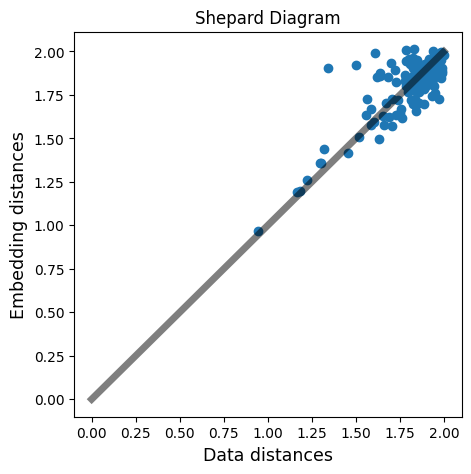

In [20]:
fig, ax = plt.subplots(figsize=(5,5))
uids = np.triu_indices(17, k=1)
ax.scatter(emb['dmat'][uids], emb['emb_mat'][uids]/emb['lambda'])
ax.plot(np.arange(3), np.arange(3), c='black', lw=5, alpha=0.5)
ax.set_xlabel('Data distances', fontsize=12.5)
ax.set_ylabel('Embedding distances', fontsize=12.5)
ax.set_title('Shepard Diagram')